In [1]:
import os
from pathlib import Path

# Set working directory
WORKDIR = Path("/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_input")
if not WORKDIR.exists():
    raise FileNotFoundError(f"Workdir not found: {WORKDIR}")
os.chdir(WORKDIR)
print("📁 Working dir:", WORKDIR)
print("📄 Files:", ", ".join(sorted(p.name for p in WORKDIR.iterdir())))
print("Files:", os.listdir('.'))

📁 Working dir: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_input
📄 Files: hypoxia_all_samples_tokens.dataset, hypoxia_downsampled.dataset
Files: ['hypoxia_all_samples_tokens.dataset', 'hypoxia_downsampled.dataset']


In [2]:
import os, sys, gc, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import torch

from datasets import load_from_disk, Dataset, DatasetDict, concatenate_datasets

# --- Warnings & GC ---
warnings.filterwarnings("ignore", category=FutureWarning)
torch.cuda.empty_cache()
gc.collect();

# --- Runtime / GPU info ---
print(f"🐍 Python: {sys.executable}")
print(f"🧠 PyTorch: {torch.__version__}")
cuda_ok = torch.cuda.is_available()
print(f"⚙️  CUDA available: {cuda_ok}")

if cuda_ok:
    dev = torch.cuda.current_device()
    name = torch.cuda.get_device_name(dev)
    alloc_gb = torch.cuda.memory_allocated() / (1024**3)
    reserv_gb = torch.cuda.memory_reserved() / (1024**3)
    print(f"🖥️  GPU[{dev}]: {name}")
    print(f"   • mem allocated: {alloc_gb:.2f} GB | reserved: {reserv_gb:.2f} GB")
    torch.cuda.empty_cache()
    gc.collect()
    alloc_gb = torch.cuda.memory_allocated() / (1024**3)
    reserv_gb = torch.cuda.memory_reserved() / (1024**3)
    print(f"   • after empty_cache → allocated: {alloc_gb:.2f} GB | reserved: {reserv_gb:.2f} GB")

# --- Optional: echo intended conda env (note: this does NOT switch the running kernel) ---
ENV_PREFIX = "/home/btanasa/miniconda3/envs/torch-cu"
os.environ["CONDA_PREFIX"] = ENV_PREFIX
os.environ["CONDA_DEFAULT_ENV"] = "torch-cu"
os.environ["RETICULATE_PYTHON"] = str(Path(ENV_PREFIX) / "bin" / "python")
print("ENV → CONDA_PREFIX:", os.environ.get("CONDA_PREFIX"))
print("ENV → CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV"))

# --- Geneformer availability (optional) ---
try:
    from geneformer import Classifier  # or TranscriptomeTokenizer
    print("✅ Geneformer import: OK")
except Exception as e:
    print("❌ Geneformer import failed:", e)

🐍 Python: /home/btanasa/miniconda3/envs/torch-cu/bin/python
🧠 PyTorch: 2.5.1
⚙️  CUDA available: True
🖥️  GPU[0]: NVIDIA L4
   • mem allocated: 0.00 GB | reserved: 0.00 GB
   • after empty_cache → allocated: 0.00 GB | reserved: 0.00 GB
ENV → CONDA_PREFIX: /home/btanasa/miniconda3/envs/torch-cu
ENV → CONDA_DEFAULT_ENV: torch-cu
✅ Geneformer import: OK


📁 WORKDIR: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_input
📦 Dataset path: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_input/hypoxia_all_samples_tokens.dataset
Type of loaded dataset: <class 'datasets.arrow_dataset.Dataset'>
Dataset summary:
Dataset({
    features: ['input_ids', 'obs_names', 'leiden', 'class', 'condition', 'broad_class', 'length'],
    num_rows: 104438
})

Dataset features (schema):
{'input_ids': List(Value('int32')), 'obs_names': Value('string'), 'leiden': Value('string'), 'class': Value('string'), 'condition': Value('string'), 'broad_class': Value('string'), 'length': Value('int64')}

First 2 records:
{'input_ids': [[2, 15927, 16559, 6428, 173, 16581, 11382, 5253, 17462, 11346, 13547, 4822, 12702, 6676, 14646, 16091, 11106, 1183, 16422, 12281, 13467, 11702, 9824, 12895, 9752, 6796, 9426, 9948, 6121, 9578, 13452, 11301, 19888, 10669, 1808, 9560, 3169, 1504

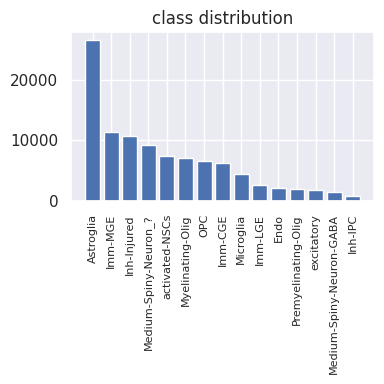


=== condition distribution ===
5d_HIE: 60633 (58.06%)
non-HIE: 25118 (24.05%)
2mo_HIE: 18687 (17.89%)


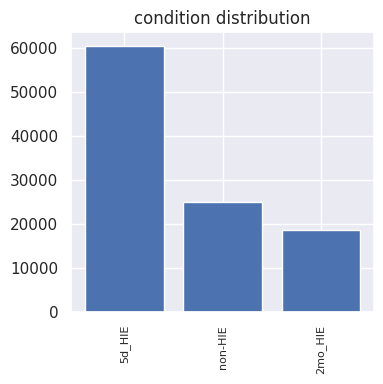


Example 'input_ids' length for row 0: 4096 (first 10): [2, 15927, 16559, 6428, 173, 16581, 11382, 5253, 17462, 11346]


In [4]:
# --- Minimal imports for this cell ---
from pathlib import Path
from collections import Counter
from datasets import load_from_disk, Dataset, DatasetDict, concatenate_datasets
import pandas as pd
import matplotlib.pyplot as plt

# --- Workdir + dataset path ---
WORKDIR = Path("/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_input")
DATASET_NAME = "hypoxia_all_samples_tokens.dataset"   # adjust if different

hypoxia_dataset = (WORKDIR / DATASET_NAME).resolve()
assert hypoxia_dataset.exists(), (
    f"Not found: {hypoxia_dataset}\n"
    f"Tip: available *.dataset dirs here: {[p.name for p in WORKDIR.glob('*.dataset')]}"
)

print("📁 WORKDIR:", WORKDIR)
print("📦 Dataset path:", hypoxia_dataset)

# --- Load ---
token_dataset = load_from_disk(str(hypoxia_dataset))

# Define ds_view (merge if DatasetDict)
if isinstance(token_dataset, DatasetDict):
    ds_view = concatenate_datasets(list(token_dataset.values()))
else:
    ds_view = token_dataset

# --- Basic info ---
print("Type of loaded dataset:", type(token_dataset))
print("Dataset summary:")
print(token_dataset)

# --- Features / schema ---
print("\nDataset features (schema):")
print(ds_view.features)

# --- Quick peek (first 2 records) ---
n_peek = min(2, len(ds_view))
print(f"\nFirst {n_peek} records:")
print(ds_view[:n_peek])

# --- Small pandas preview (safe) ---
HEAD_N = min(5, len(ds_view))
df_head = ds_view.select(range(HEAD_N)).to_pandas()
print("\nHead of the dataset as pandas DataFrame:")
print(df_head)

# Keep for later steps
original_dataset = token_dataset

# --- Optional: quick distributions if present ---
cols_to_check = ["class", "condition"]
for col in cols_to_check:
    if col in ds_view.column_names:
        c = Counter(ds_view[col])
        total = sum(c.values())
        print(f"\n=== {col} distribution ===")
        for k, v in c.most_common(15):
            print(f"{k}: {v} ({v/total*100:.2f}%)")

        # Small bar plot (top 15) — shown inline
        labels, values = zip(*c.most_common(15))
        plt.figure(figsize=(4, 4))
        plt.bar(range(len(values)), values)
        plt.xticks(range(len(values)), labels, rotation=90, fontsize=8)
        plt.title(f"{col} distribution")
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nColumn '{col}' not found. Available: {ds_view.column_names}")

# --- Optional: input_ids shape sanity (if present) ---
if "input_ids" in ds_view.column_names and len(ds_view) > 0:
    ex0 = ds_view[0]["input_ids"]
    print(f"\nExample 'input_ids' length for row 0: {len(ex0)} (first 10): {ex0[:10]}")


Cells × Condition — COUNTS (original, limited to displayed classes)


condition,2mo_HIE,5d_HIE,non-HIE
class,,,
Astroglia,62,15704,10782
Imm-MGE,292,7677,3386
Inh-Injured,242,9562,885
Medium-Spiny-Neuron_?,799,8297,172
activated-NSCs,4618,1862,985
Myelinating-Olig,6090,347,607
OPC,1899,3117,1489
Imm-CGE,1117,3191,1895
Microglia,264,3064,1030



Cells × Condition — COLUMN % (within condition)


condition,2mo_HIE,5d_HIE,non-HIE
class,,,
Astroglia,0.33,25.92,42.96
Imm-MGE,1.56,12.67,13.49
Inh-Injured,1.30,15.78,3.53
Medium-Spiny-Neuron_?,4.28,13.70,0.69
activated-NSCs,24.71,3.07,3.93
Myelinating-Olig,32.59,0.57,2.42
OPC,10.16,5.15,5.93
Imm-CGE,5.98,5.27,7.55
Microglia,1.41,5.06,4.10


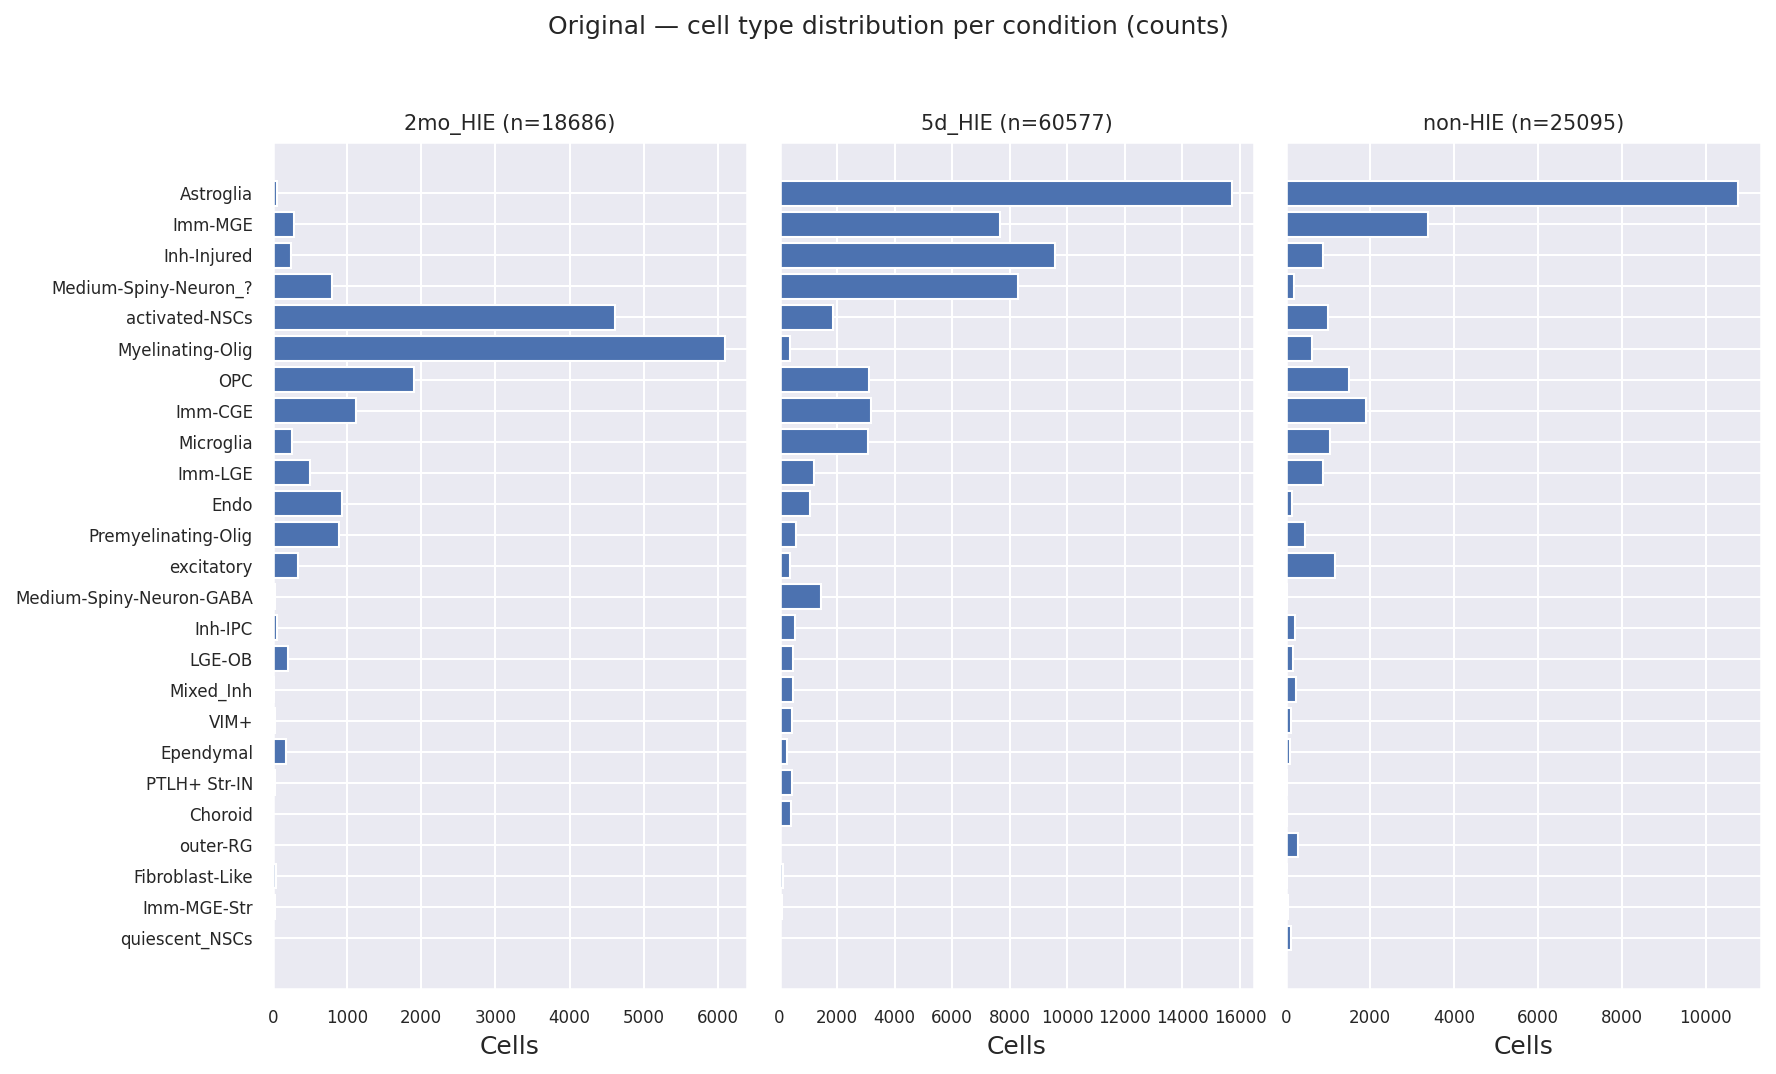

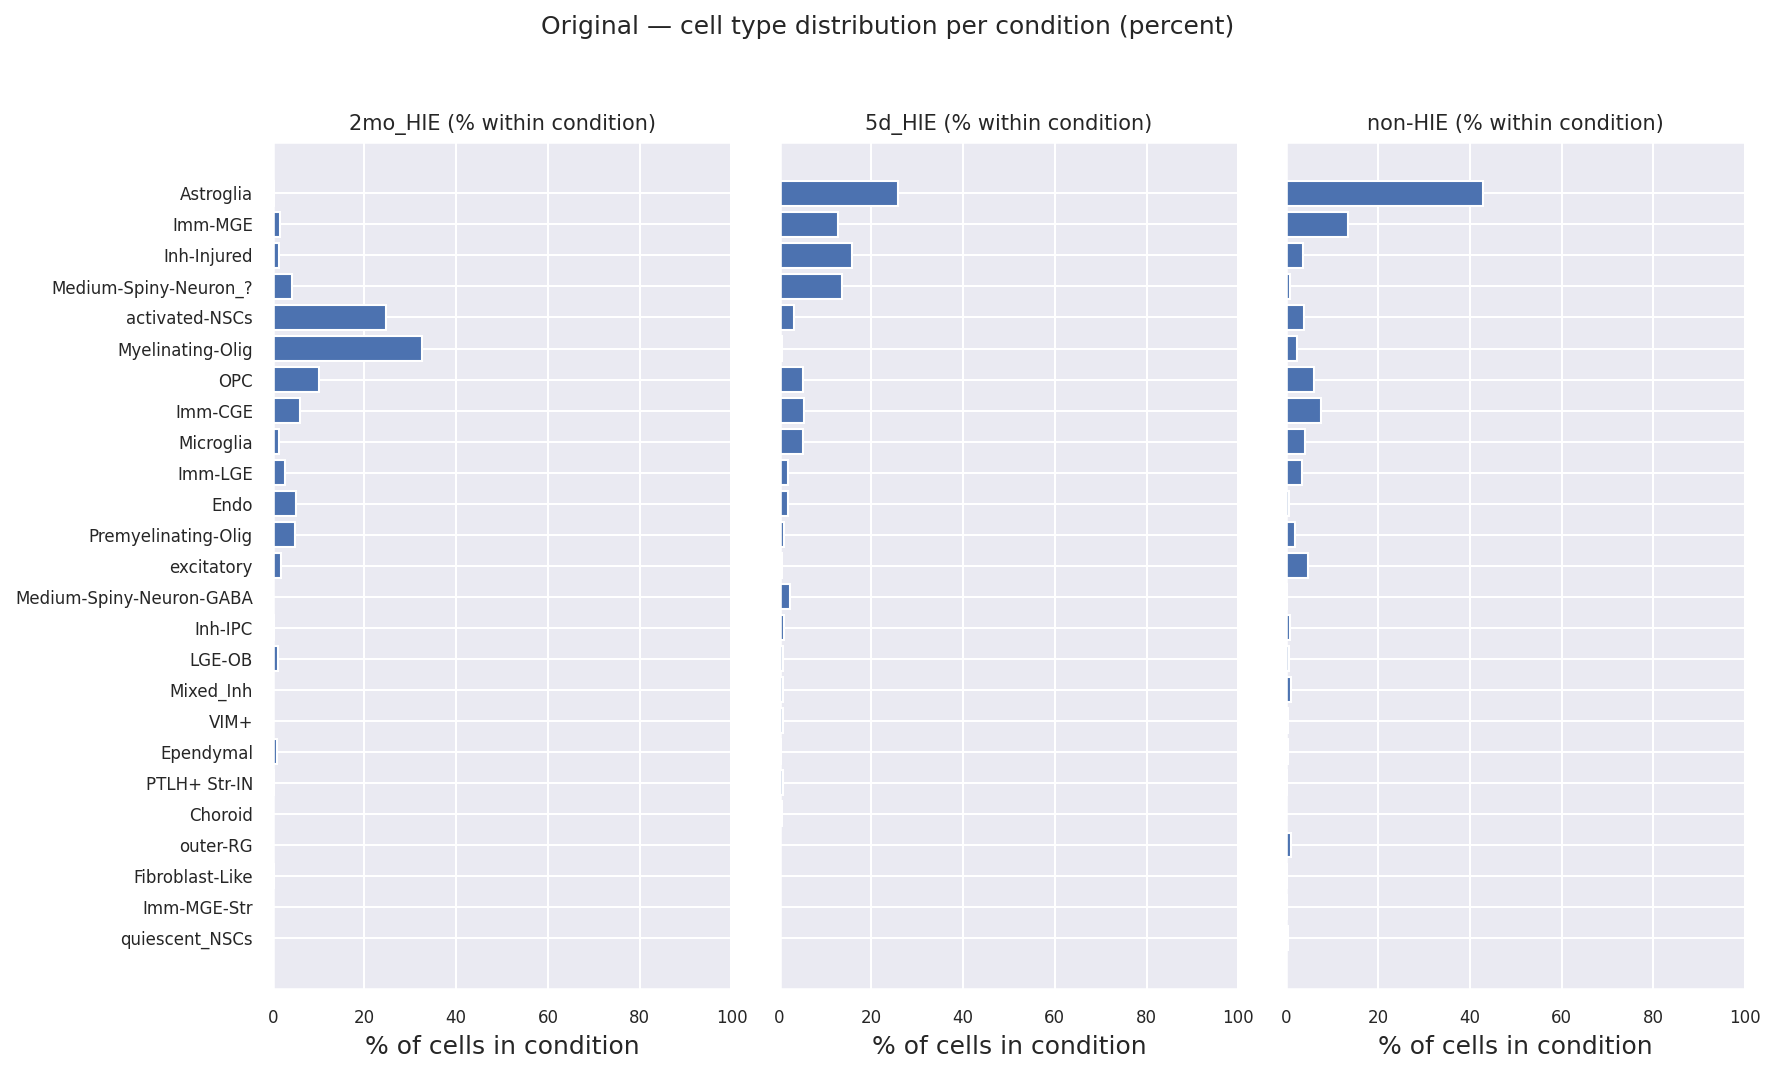

Saved figures to: original_per_condition/


In [5]:
# === Per-condition distributions for the ORIGINAL dataset `original_dataset` ===
from datasets import Dataset, DatasetDict, concatenate_datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- config ---
OUTDIR = "original_per_condition"
TOP_N  = 25        # limit to top-N classes overall for readability; set None for all
DPI    = 150
os.makedirs(OUTDIR, exist_ok=True)

# Normalize to a single Dataset
orig_ds = original_dataset
if isinstance(orig_ds, DatasetDict):
    orig_ds = concatenate_datasets(list(orig_ds.values()))
elif not isinstance(orig_ds, Dataset):
    raise TypeError(f"Unexpected type: {type(orig_ds)}")

# Build tidy DataFrame
df_orig = pd.DataFrame({"class": orig_ds["class"], "condition": orig_ds["condition"]})

# Counts: rows = class, cols = condition
counts = pd.crosstab(df_orig["class"], df_orig["condition"]).sort_index()
conditions = counts.columns.tolist()

# Choose a consistent class order (top-N by overall total)
if TOP_N is not None:
    class_order = counts.sum(axis=1).sort_values(ascending=False).head(TOP_N).index.tolist()
    counts = counts.loc[class_order]
else:
    class_order = counts.index.tolist()

# Column % (within each condition)
colpct = (counts.div(counts.sum(axis=0).replace(0, np.nan), axis=1) * 100.0).fillna(0.0).round(2)

# --- Print tables ---
from IPython.display import display
print("Cells × Condition — COUNTS (original, limited to displayed classes)")
display(counts)
print("\nCells × Condition — COLUMN % (within condition)")
display(colpct)

# --- Plot: per-condition barh (COUNTS) ---
n_cond  = len(conditions)
n_class = len(class_order)
fig_h   = max(6, 0.28 * n_class)

fig, axes = plt.subplots(1, n_cond, figsize=(4.0 * n_cond, fig_h), sharey=True, dpi=DPI)
if n_cond == 1:
    axes = [axes]

ypos = np.arange(n_class)
for ax, cond in zip(axes, conditions):
    vals = counts[cond].reindex(class_order).values
    ax.barh(ypos, vals)
    ax.set_title(f"{cond} (n={int(vals.sum())})", fontsize=10)
    ax.set_yticks(ypos)
    ax.set_yticklabels(class_order, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Cells")
    ax.tick_params(axis="x", labelsize=8)

fig.suptitle("Original — cell type distribution per condition (counts)", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(OUTDIR, "per_condition_counts_barh.png"), dpi=DPI, bbox_inches="tight")
plt.close(fig)

# --- Plot: per-condition barh (COLUMN %) ---
fig, axes = plt.subplots(1, n_cond, figsize=(4.0 * n_cond, fig_h), sharey=True, dpi=DPI)
if n_cond == 1:
    axes = [axes]

for ax, cond in zip(axes, conditions):
    vals = colpct[cond].reindex(class_order).values
    ax.barh(ypos, vals)
    ax.set_title(f"{cond} (% within condition)", fontsize=10)
    ax.set_yticks(ypos)
    ax.set_yticklabels(class_order, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of cells in condition")
    ax.tick_params(axis="x", labelsize=8)

fig.suptitle("Original — cell type distribution per condition (percent)", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(OUTDIR, "per_condition_colpct_barh.png"), dpi=DPI, bbox_inches="tight")
plt.close(fig)

print(f"Saved figures to: {OUTDIR}/")


In [6]:
# Perform the stratified subsampling

In [7]:
# Joint (class × condition) stratified down-sampling

from datasets import Dataset, DatasetDict, concatenate_datasets
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
import math, random, os, shutil

# ========= CONFIG =========
TARGET_N   = 2000          # total cells after downsampling
RARE_FRAC  = 0.05          # drop classes <5% of ORIGINAL dataset
SEED       = 42
SAVE_PATH  = output_dir if "output_dir" in globals() else "./hypoxia_all_samples_downsampled.dataset"
NUM_PROC   = 8
# ==========================

# 0) Normalize to a single Dataset
ds = original_dataset
if isinstance(ds, DatasetDict):
    ds = concatenate_datasets(list(ds.values()))
elif not isinstance(ds, Dataset):
    raise TypeError(f"Unexpected type: {type(ds)}")

# 1) Sanity checks
for col in ["class", "condition"]:
    if col not in ds.column_names:
        raise KeyError(f"Missing column '{col}'. Available: {ds.column_names}")

print(f"Start: {len(ds):,} cells")

# 2) Drop classes occurring in <5% of ORIGINAL dataset
total0 = len(ds)
class_counts0 = Counter(ds["class"])
keep_classes = [k for k, v in class_counts0.items() if v / total0 >= RARE_FRAC]
ds = ds.filter(lambda ex, keep=keep_classes: ex["class"] in keep, num_proc=NUM_PROC)
print(f"After 5% class filter → {len(ds):,} cells; kept {len(keep_classes)} classes")

# 3) If no downsampling needed, just shuffle
if TARGET_N >= len(ds):
    ds_down = ds.shuffle(seed=SEED)
    print("TARGET_N ≥ filtered size; skipping downsampling (shuffled only).")
else:
    # --- joint (class||condition) quotas via largest remainder (Hamilton) ---
    joint_keys   = [f"{c}||{k}" for c, k in zip(ds["class"], ds["condition"])]
    joint_counts = Counter(joint_keys)
    total        = sum(joint_counts.values())

    exact = {k: TARGET_N * (v / total) for k, v in joint_counts.items()}
    base  = {k: int(math.floor(x)) for k, x in exact.items()}
    used  = sum(base.values())
    # distribute leftover by largest fractional parts
    remainder = sorted(((exact[k] - base[k], k) for k in base), reverse=True)
    for i in range(TARGET_N - used):
        _, k = remainder[i]
        base[k] += 1

    # sample per joint bucket
    parts = []
    for key, q in base.items():
        if q <= 0: 
            continue
        cls, cond = key.split("||", 1)
        sub = ds.filter(lambda ex, a=cls, b=cond: (ex["class"] == a) and (ex["condition"] == b),
                        num_proc=NUM_PROC)
        q = min(q, len(sub))
        if q > 0:
            parts.append(sub.shuffle(seed=SEED).select(range(q)))

    ds_down = concatenate_datasets(parts).shuffle(seed=SEED)

print(f"Downsampled size: {len(ds_down):,} (target={TARGET_N})")

# 4) Quick tables (counts & row-%)
df = pd.DataFrame({"class": ds_down["class"], "condition": ds_down["condition"]})
ct_counts  = pd.crosstab(df["class"], df["condition"]).sort_index()
ct_rowpct  = (ct_counts.div(ct_counts.sum(axis=1).replace(0, np.nan), axis=0) * 100).fillna(0).round(2)

print("\nCells × Condition — COUNTS (downsampled)")
display(ct_counts)
print("\nCells × Condition — ROW % within class (downsampled)")
display(ct_rowpct)

# 5) Save
if SAVE_PATH:
    if os.path.exists(SAVE_PATH):
        shutil.rmtree(SAVE_PATH)
    ds_down.save_to_disk(SAVE_PATH)
    print(f"\n✅ Saved downsampled dataset to: {SAVE_PATH}")


Start: 104,438 cells
After 5% class filter → 85,077 cells; kept 8 classes
Downsampled size: 2,000 (target=2000)

Cells × Condition — COUNTS (downsampled)


condition,2mo_HIE,5d_HIE,non-HIE
class,,,
Astroglia,1,369,253
Imm-CGE,26,75,45
Imm-MGE,7,180,80
Inh-Injured,6,225,21
Medium-Spiny-Neuron_?,19,195,4
Myelinating-Olig,143,8,14
OPC,45,73,35
activated-NSCs,109,44,23



Cells × Condition — ROW % within class (downsampled)


condition,2mo_HIE,5d_HIE,non-HIE
class,,,
Astroglia,0.16,59.23,40.61
Imm-CGE,17.81,51.37,30.82
Imm-MGE,2.62,67.42,29.96
Inh-Injured,2.38,89.29,8.33
Medium-Spiny-Neuron_?,8.72,89.45,1.83
Myelinating-Olig,86.67,4.85,8.48
OPC,29.41,47.71,22.88
activated-NSCs,61.93,25.00,13.07



✅ Saved downsampled dataset to: ./hypoxia_all_samples_downsampled.dataset


In [8]:
# Row % within class
# What it answers: “Within this cell class, how are its cells split across conditions?”

# Column % within condition
# What it answers: “Within this condition, how are its cells split across classes?”

# Condition-only stratification: you down-sample by columns (conditions) only. Column proportions are preserved; row/class proportions may shift.
# Class-only stratification: you down-sample by rows (classes) only. Row proportions are preserved; column/condition proportions may shift.
# Joint (class × condition) stratification (what we implemented): you down-sample by cells of the contingency table (each class–condition pair). 
# This effectively preserves both row and column distributions (marginals) as a consequence of preserving the joint distribution—allowing 
# for tiny rounding differences and any buckets with too few cells (which can end up at 0 after downsampling)

Cells × Condition — COUNTS (downsampled, limited to displayed classes)


condition,2mo_HIE,5d_HIE,non-HIE
class,,,
Astroglia,62,15704,10782
Imm-MGE,292,7677,3386
Inh-Injured,242,9562,885
Medium-Spiny-Neuron_?,799,8297,172
activated-NSCs,4618,1862,985
Myelinating-Olig,6090,347,607
OPC,1899,3117,1489
Imm-CGE,1117,3191,1895



Cells × Condition — COLUMN % (within condition)


condition,2mo_HIE,5d_HIE,non-HIE
class,,,
Astroglia,0.41,31.56,53.37
Imm-MGE,1.93,15.43,16.76
Inh-Injured,1.60,19.22,4.38
Medium-Spiny-Neuron_?,5.28,16.68,0.85
activated-NSCs,30.54,3.74,4.88
Myelinating-Olig,40.28,0.70,3.00
OPC,12.56,6.26,7.37
Imm-CGE,7.39,6.41,9.38


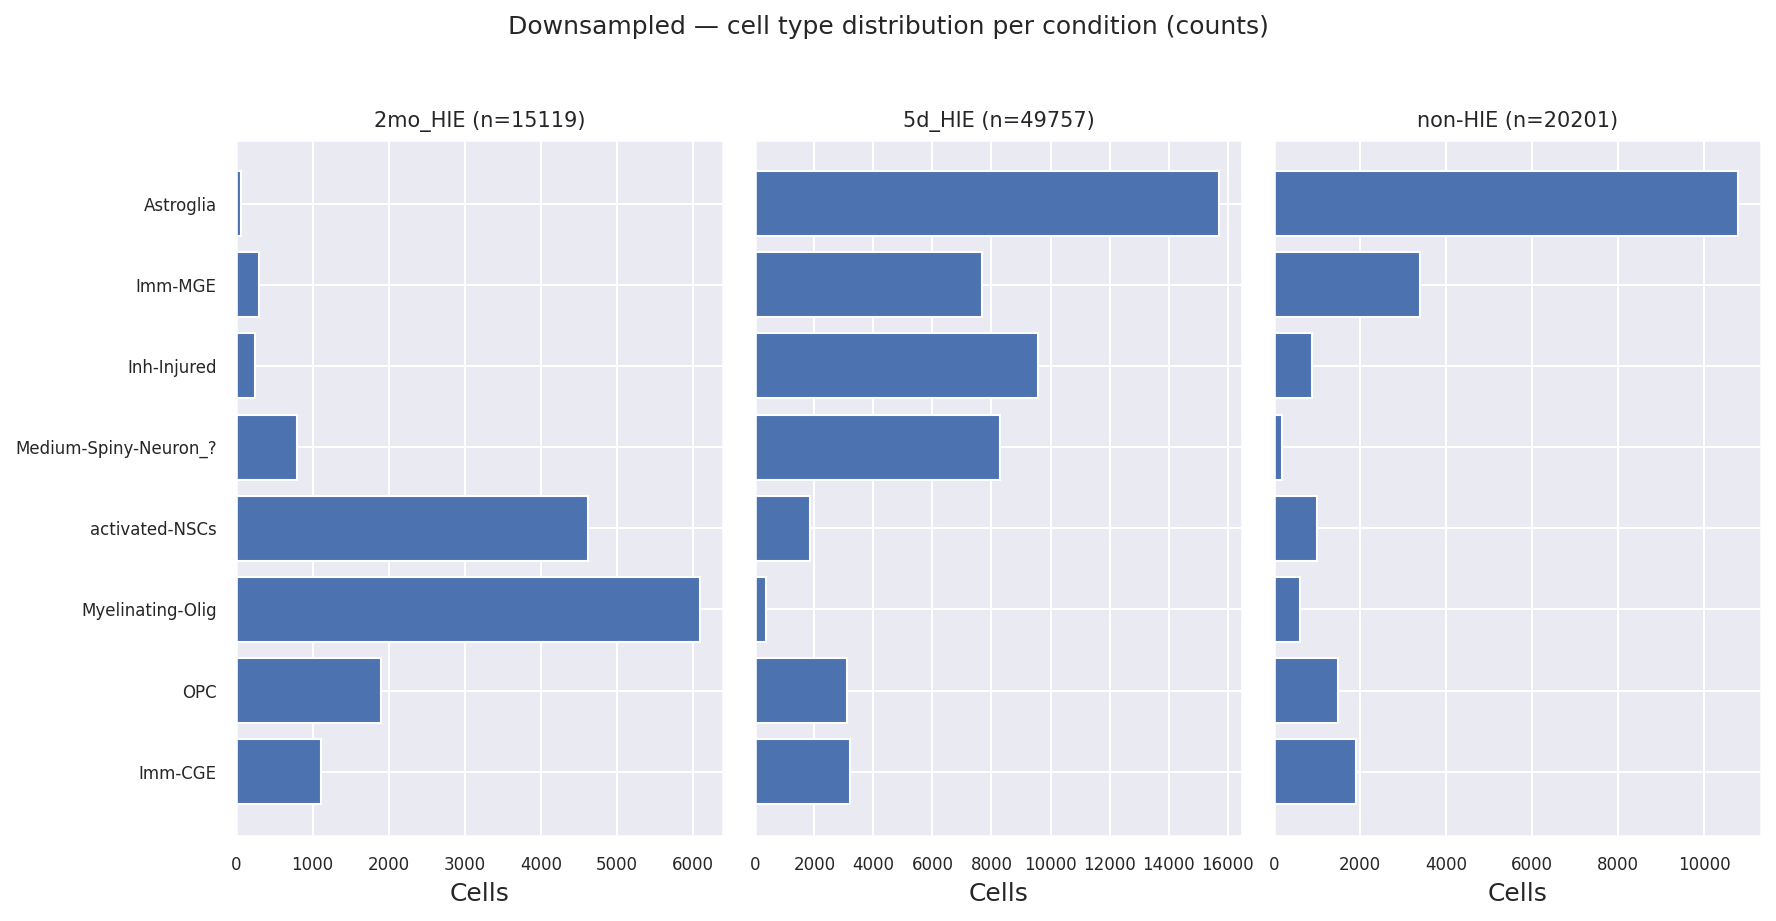

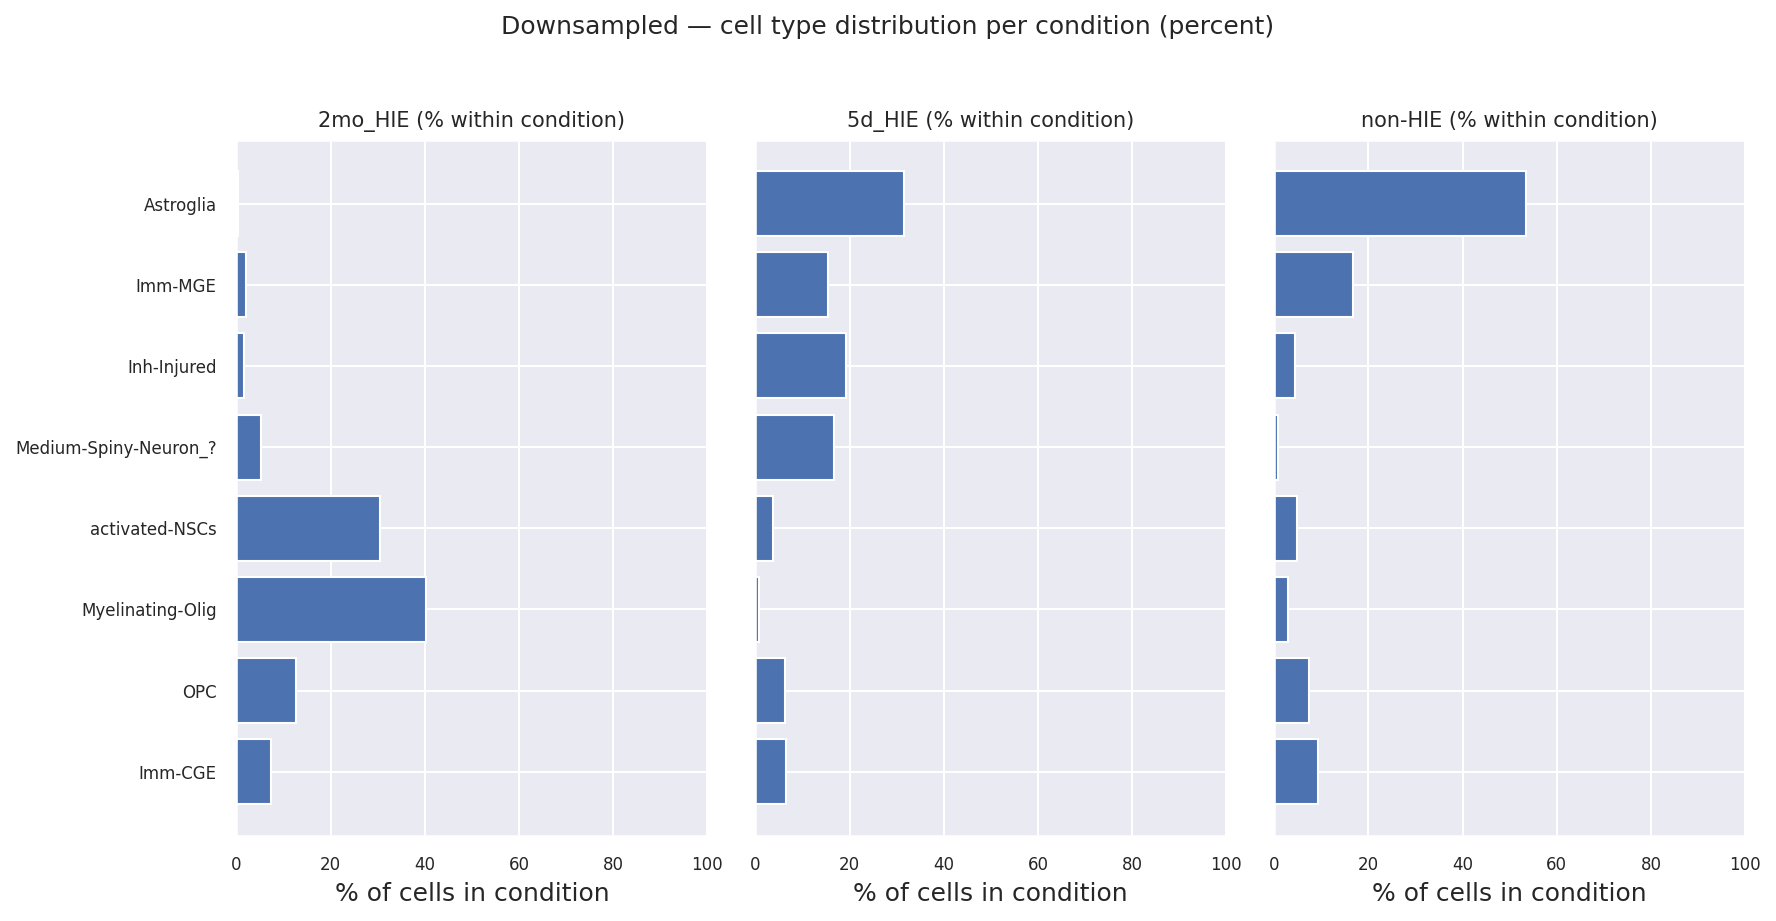

Saved figures to: downsampled_per_condition/


In [9]:
# === Per-condition distributions for the DOWNSAMPLED dataset `ds` ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- config ---
OUTDIR = "downsampled_per_condition"
TOP_N  = 25        # limit to top-N classes overall for readability; set None for all
DPI    = 150
os.makedirs(OUTDIR, exist_ok=True)

# Build a tidy DataFrame from the downsampled HF dataset
df_down = pd.DataFrame({"class": ds["class"], "condition": ds["condition"]})

# Counts: rows = class, cols = condition
counts = pd.crosstab(df_down["class"], df_down["condition"]).sort_index()
conditions = counts.columns.tolist()

# Choose a consistent class order (top-N by overall total)
if TOP_N is not None:
    class_order = counts.sum(axis=1).sort_values(ascending=False).head(TOP_N).index.tolist()
    counts = counts.loc[class_order]
else:
    class_order = counts.index.tolist()

# Column % (within each condition)
colpct = (counts.div(counts.sum(axis=0).replace(0, np.nan), axis=1) * 100.0).fillna(0.0).round(2)

# --- Print tables ---
print("Cells × Condition — COUNTS (downsampled, limited to displayed classes)")
display(counts)
print("\nCells × Condition — COLUMN % (within condition)")
display(colpct)

# --- Plot: per-condition barh (COUNTS) ---
n_cond  = len(conditions)
n_class = len(class_order)
fig_h   = max(6, 0.28 * n_class)

fig, axes = plt.subplots(1, n_cond, figsize=(4.0 * n_cond, fig_h), sharey=True, dpi=DPI)
if n_cond == 1:
    axes = [axes]

ypos = np.arange(n_class)
for ax, cond in zip(axes, conditions):
    vals = counts[cond].reindex(class_order).values
    ax.barh(ypos, vals)
    ax.set_title(f"{cond} (n={int(vals.sum())})", fontsize=10)
    ax.set_yticks(ypos)
    ax.set_yticklabels(class_order, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Cells")
    ax.tick_params(axis="x", labelsize=8)

fig.suptitle("Downsampled — cell type distribution per condition (counts)", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(OUTDIR, "per_condition_counts_barh.png"), dpi=DPI, bbox_inches="tight")
plt.close(fig)

# --- Plot: per-condition barh (COLUMN %) ---
fig, axes = plt.subplots(1, n_cond, figsize=(4.0 * n_cond, fig_h), sharey=True, dpi=DPI)
if n_cond == 1:
    axes = [axes]

for ax, cond in zip(axes, conditions):
    vals = colpct[cond].reindex(class_order).values
    ax.barh(ypos, vals)
    ax.set_title(f"{cond} (% within condition)", fontsize=10)
    ax.set_yticks(ypos)
    ax.set_yticklabels(class_order, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of cells in condition")
    ax.tick_params(axis="x", labelsize=8)

fig.suptitle("Downsampled — cell type distribution per condition (percent)", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(OUTDIR, "per_condition_colpct_barh.png"), dpi=DPI, bbox_inches="tight")
plt.close(fig)

print(f"Saved figures to: {OUTDIR}/")



=== 2mo_HIE — % within condition (original vs downsampled) ===


,original_%,downsampled_%
class,,
Astroglia,0.33,0.41
Imm-MGE,1.56,1.93
Inh-Injured,1.30,1.60
Medium-Spiny-Neuron_?,4.28,5.28
activated-NSCs,24.71,30.54
Myelinating-Olig,32.59,40.28
OPC,10.16,12.56
Imm-CGE,5.98,7.39
Microglia,1.41,0.00


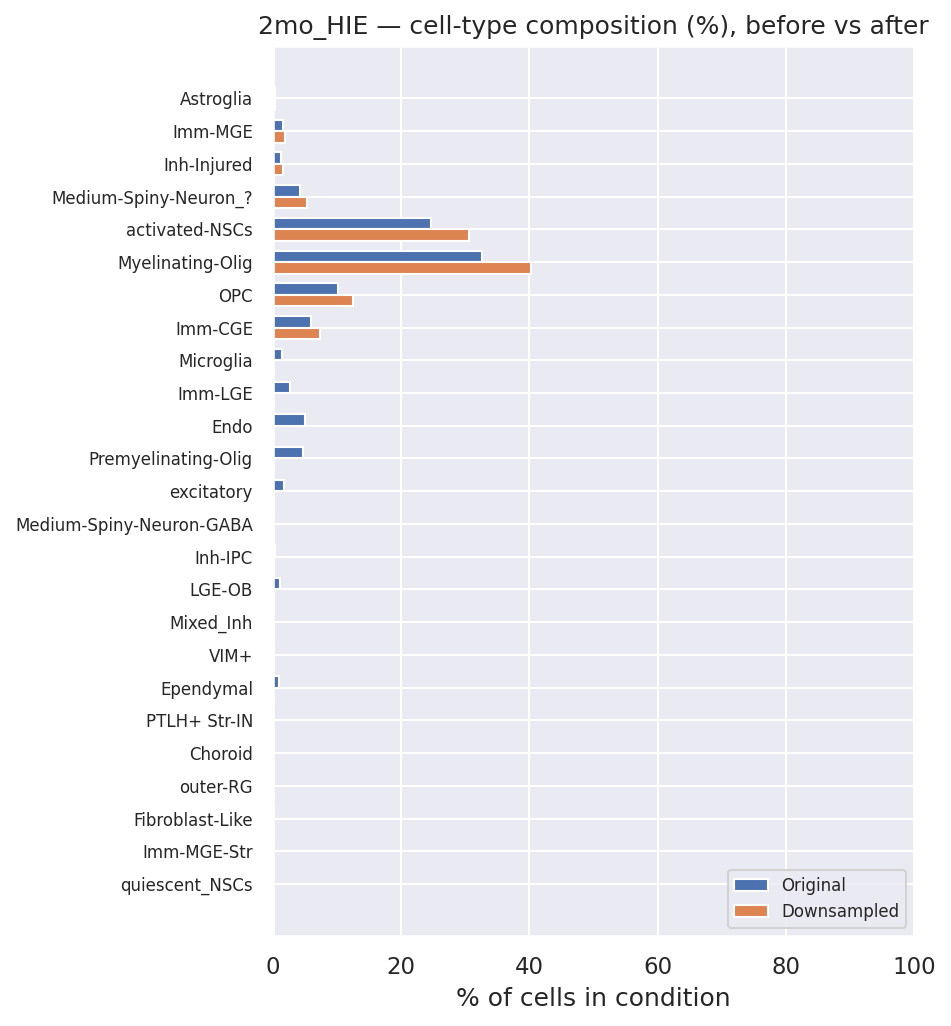


=== 5d_HIE — % within condition (original vs downsampled) ===


,original_%,downsampled_%
class,,
Astroglia,25.90,31.56
Imm-MGE,12.66,15.43
Inh-Injured,15.77,19.22
Medium-Spiny-Neuron_?,13.68,16.68
activated-NSCs,3.07,3.74
Myelinating-Olig,0.57,0.70
OPC,5.14,6.26
Imm-CGE,5.26,6.41
Microglia,5.05,0.00


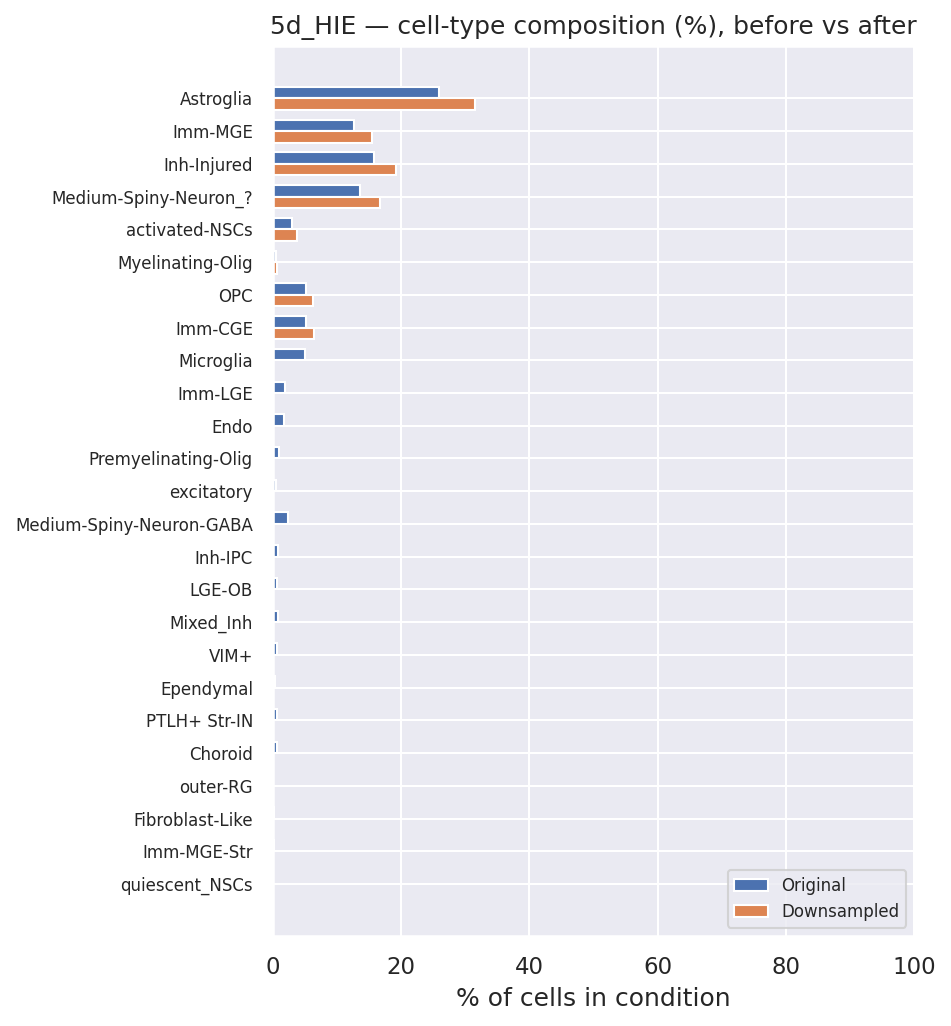


=== non-HIE — % within condition (original vs downsampled) ===


,original_%,downsampled_%
class,,
Astroglia,42.93,53.37
Imm-MGE,13.48,16.76
Inh-Injured,3.52,4.38
Medium-Spiny-Neuron_?,0.68,0.85
activated-NSCs,3.92,4.88
Myelinating-Olig,2.42,3.00
OPC,5.93,7.37
Imm-CGE,7.54,9.38
Microglia,4.10,0.00


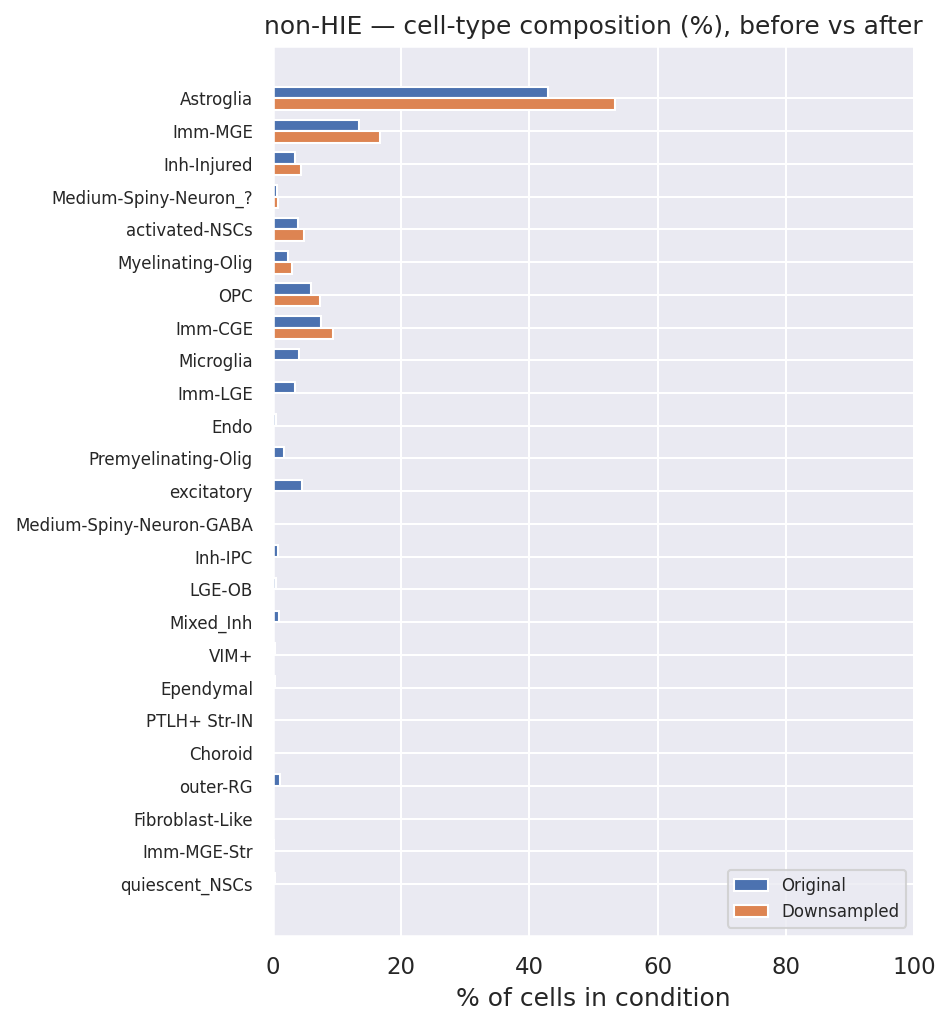


Saved figures and CSVs in: per_condition_before_vs_after/


In [10]:
# Compare ORIGINAL vs DOWNSAMPLED percentages per cell type, for each condition

from datasets import Dataset, DatasetDict, concatenate_datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- config ---
OUTDIR = "per_condition_before_vs_after"
TOP_N  = 25     # limit to top-N classes overall for readability; set None to show all
DPI    = 150
os.makedirs(OUTDIR, exist_ok=True)

# --- pick datasets ---
# original dataset
orig = original_dataset
if isinstance(orig, DatasetDict):
    orig = concatenate_datasets(list(orig.values()))
elif not isinstance(orig, Dataset):
    raise TypeError(f"Unexpected type for original_dataset: {type(orig)}")

# downsampled dataset (use `ds` if defined, else `ds_down`)
try:
    down = ds
except NameError:
    try:
        down = ds_down
    except NameError:
        raise NameError("Please define your downsampled dataset as `ds` or `ds_down`.")

if isinstance(down, DatasetDict):
    down = concatenate_datasets(list(down.values()))
elif not isinstance(down, Dataset):
    raise TypeError(f"Unexpected type for downsampled dataset: {type(down)}")

# --- sanity checks ---
for col in ["class", "condition"]:
    if col not in orig.column_names:
        raise KeyError(f"Column '{col}' missing in original: {orig.column_names}")
    if col not in down.column_names:
        raise KeyError(f"Column '{col}' missing in downsampled: {down.column_names}")

# --- tidy frames ---
df_orig = pd.DataFrame({"class": orig["class"], "condition": orig["condition"]})
df_down = pd.DataFrame({"class": down["class"], "condition": down["condition"]})

# --- counts tables and convert to COLUMN % (within condition) ---
cnt_orig = pd.crosstab(df_orig["class"], df_orig["condition"]).sort_index()
cnt_down = pd.crosstab(df_down["class"], df_down["condition"]).sort_index()

all_conditions = sorted(set(cnt_orig.columns).union(cnt_down.columns))
cnt_orig = cnt_orig.reindex(columns=all_conditions, fill_value=0)
cnt_down = cnt_down.reindex(columns=all_conditions, fill_value=0)

colpct_orig = (cnt_orig.div(cnt_orig.sum(axis=0).replace(0, np.nan), axis=1) * 100).fillna(0).round(2)
colpct_down = (cnt_down.div(cnt_down.sum(axis=0).replace(0, np.nan), axis=1) * 100).fillna(0).round(2)

# pick a consistent class order (top-N by combined total across both datasets & all conditions)
combined_totals = cnt_orig.sum(axis=1).add(cnt_down.sum(axis=1), fill_value=0)
class_order = combined_totals.sort_values(ascending=False).index.tolist()
if TOP_N is not None:
    class_order = class_order[:TOP_N]

# --- per-condition plots & tables ---
for cond in all_conditions:
    # build per-condition tables (reindexed to shared class_order)
    t_orig = colpct_orig.get(cond, pd.Series(dtype=float)).reindex(class_order).fillna(0.0)
    t_down = colpct_down.get(cond, pd.Series(dtype=float)).reindex(class_order).fillna(0.0)

    # print combined table
    table = pd.DataFrame({
        "original_%": t_orig,
        "downsampled_%": t_down,
    })
    print(f"\n=== {cond} — % within condition (original vs downsampled) ===")
    display(table)

    # save CSV
    table.to_csv(os.path.join(OUTDIR, f"{cond}_percent_within_condition_before_after.csv"))

    # plot grouped horizontal bars
    y = np.arange(len(class_order))
    bar_h = 0.35

    fig_h = max(6, 0.28 * len(class_order))
    fig, ax = plt.subplots(figsize=(6.5, fig_h), dpi=DPI)

    ax.barh(y - bar_h/2, t_orig.values, height=bar_h, label="Original")
    ax.barh(y + bar_h/2, t_down.values, height=bar_h, label="Downsampled")

    ax.set_yticks(y)
    ax.set_yticklabels(class_order, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of cells in condition")
    ax.set_title(f"{cond} — cell-type composition (%), before vs after")
    ax.legend(fontsize=8, loc="lower right", ncol=1)

    fig.tight_layout()
    plt.show()
    fig.savefig(os.path.join(OUTDIR, f"{cond}_before_vs_after_percent_barh.png"),
                dpi=DPI, bbox_inches="tight")
    plt.close(fig)

print(f"\nSaved figures and CSVs in: {OUTDIR}/")


In [ ]:
print(OUTDIR)